# Exercise 1

## A: Activity of random pixels

In [1]:
import numpy as np
import pylab as pl
import matplotlib.pyplot as plt

# CaImAn funtions and objects
import caiman as cm
from caiman.motion_correction import MotionCorrect
from caiman.source_extraction.cnmf import params as params
from caiman.source_extraction import cnmf
from caiman.source_extraction.cnmf.cnmf import load_CNMF

import sys
import os
sys.path.append(os.path.abspath("neural-data-master/02-calcium_imaging/code"))
from utils import download_data

import seaborn as sns
sns.set_theme(context='notebook',style='white',font_scale=1.5)

download_data('https://surfdrive.surf.nl/files/index.php/s/yQT6yv34jDu6csE')

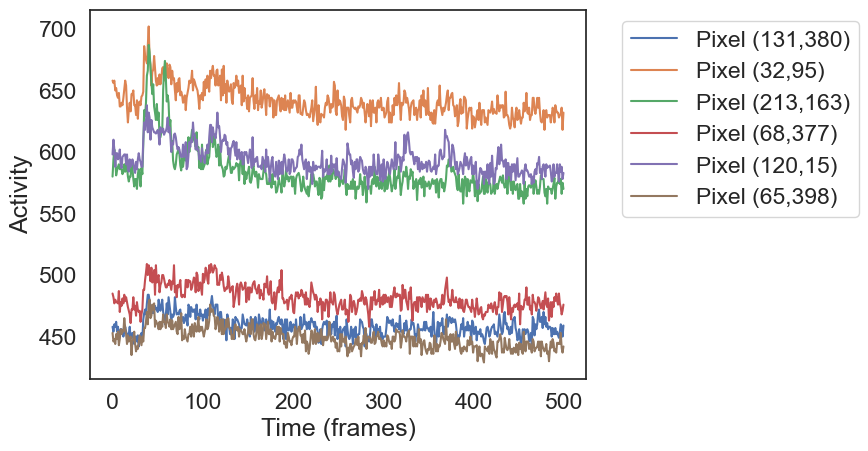

In [14]:
input_tif_file_path = 'data/caiman_video_trial_0.tif' 
ROI = cm.load(input_tif_file_path) #load the data from the region of interest

T, h, w = ROI.shape #time frames, height, width
all_values = [] #will count all the values of the pixels

N = 6 #N pixels
pixels = []
for n in range(N):
    i = np.random.randint(h) #select N random height coordinates 
    j = np.random.randint(w) #select N random width coordinates 
    pixels.append((i, j))

for (i, j) in pixels:
    evolution = ROI[:, i, j] #get the activity value for those N random pixels
    all_values.append(evolution)
    plt.plot(evolution, label=f'Pixel ({i},{j})')

plt.xlabel("Time (frames)")
plt.ylabel("Activity")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## B: Pixel values

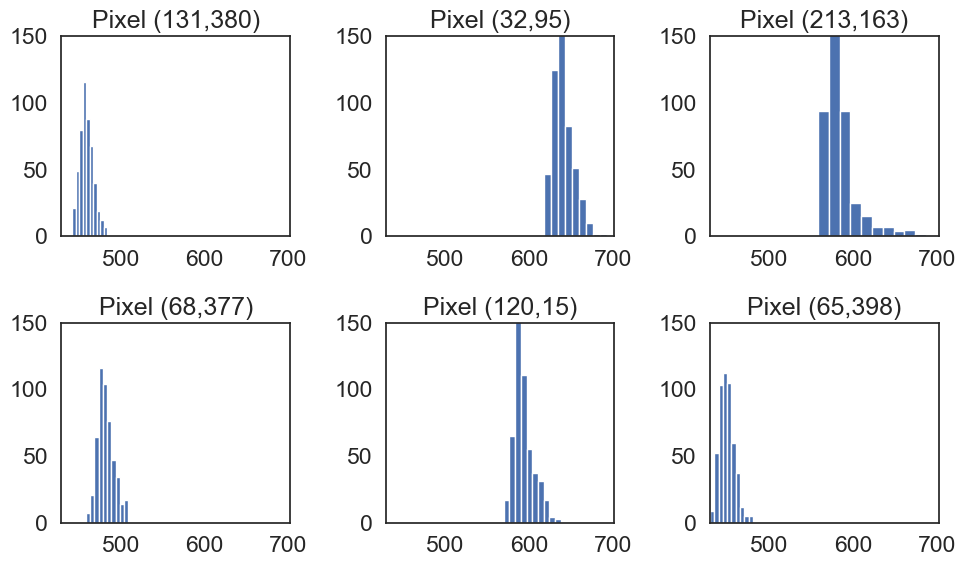

In [15]:
fig, axes = plt.subplots(2, 3, figsize=(10, 6))
axes = axes.flatten() #was needed to fix an error

all_values = np.concatenate(all_values)
x_min, x_max = all_values.min(), all_values.max() #calculate the x-axes minimum and maximum

for idx, (i, j) in enumerate(pixels):
    evolution = ROI[:, i, j]
    axes[idx].hist(evolution, bins=10) #plot for each pixel the hisogram: plots the count against the activity levels
    axes[idx].set_title(f'Pixel ({i},{j})')
    axes[idx].set_xlim(x_min, x_max) #set all the x-axes the same to really compare each pixel
    axes[idx].set_ylim(0, 150) 

plt.tight_layout()
plt.show()

> If the histogram has a very narrow peak and (almost) no tail, then these pixels are probably background pixels since their activity stays constant. If the histogram has a tail to the right, then there was a spike and the pixel probably belongs to a neuron. We can also compare the baseline: if the histogram is more to the left, it has lower activity values so background pixels. And if the histogram is more to the right, it has higher values and so it must be a neuron pixel. 

> One pixel is not a neuron so it only captures part of the information about the full neuron. Also looking at only one data point makes the effects of noise very big. So it would be better to look at complete neurons instead.

# Exercise 2

## High pass filter space

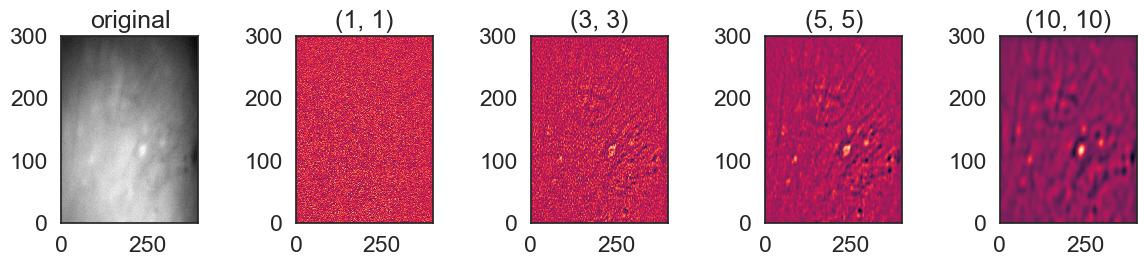

In [4]:
from caiman.motion_correction import high_pass_filter_space

# load video and take one frame
movie = cm.load('data/caiman_video_trial_0.tif')
frame = movie[0]

# different filter sizes
gSig_filt = [(1,1), (3,3), (5,5), (10,10)]

fig, axes = plt.subplots(1, len(gSig_filt)+1, figsize=(12, 3))

# original
axes[0].pcolormesh(frame, cmap='gray')
axes[0].set_title("original")

# filtered versions
for i, sigma in enumerate(gSig_filt):
    filtered = high_pass_filter_space(frame, sigma) #use high_pass_filter_space function from caiman
    axes[i+1].pcolormesh(filtered)
    axes[i+1].set_title(str(sigma))

plt.tight_layout()
plt.show()

## Crispness
Different gSig_filt will affect how smooth or sharp the borders of different parts of the image are defined. Small filter size will have lower pixel by pixel correlation values, which can be seen in (1,1) where it is very grainy. Big filter size (like (10,10)) can oversmooth the image to the point where everything will be highly correlated, and so look unsharp.

## Pnevmatikakis et al.
According to Pnevmatikakis et al., piecewise-rigid motion correction is needed because brain movement is not the same everywhere in the image. Different parts of the brain can shift or deform slightly differently, so treating the whole image as one rigid block is not accurate enough. The brain tissue itself is elastic and can stretch or bend slightly due to natural movements.
In addition, the way the microscope scans the image line by line can introduce small distortions within a single frame since they are scanned at slightly different times. 
Because of all these effects, motion is not uniform across the image, which is why correcting it in smaller pieces works better than using one single global correction.

## Crispness compared to different spatial filter sizes

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParam

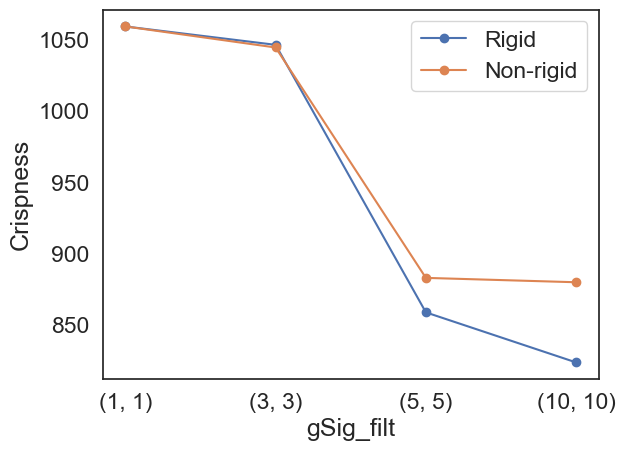

In [5]:
crisp_rigid = []
crisp_nonrigid = []
winsize = 100
swap_dim = False
resize_fact_flow = .1 

parameters_motion_correction = { 'pw_rigid': True,       # flag for performing piecewise-rigid motion correction (otherwise just rigid)
                                'max_shifts': (25, 25),  # maximum allowed rigid shift in pixels (view the movie to get a sense of motion)
                                'niter_rig': 1 ,
                                'strides': (48, 48),     # create a new patch every x pixels for pw-rigid correction
                                'overlaps': (96, 96),    # overlap between pathes (size of patch strides+overlaps)
                                'upsample_factor_grid': 1,
                                'num_frames_split': 80,  # length in frames of each chunk of the movie (to be processed in parallel)
                                'max_deviation_rigid': 15, # maximum deviation allowed for patch with respect to rigid shifts
                                'shifts_opencv': True, 
                                'use_cuda': False, 
                                'nonneg_movie': True,
                                'border_nan': 'copy'}
original_movie = cm.load(input_tif_file_path)
parameters_motion_correction['min_mov'] = np.min(original_movie) 

for gSig in gSig_filt:

    # update parameters
    parameters_motion_correction['gSig_filt'] = gSig

    opts = params.CNMFParams(params_dict=parameters_motion_correction)

    # motion correction object
    mc = MotionCorrect(input_tif_file_path, dview=None, **opts.get_group('motion'))

    # rigid correction
    mc.motion_correct_rigid(save_movie=True)

    # non-rigid correction
    mc.motion_correct_pwrigid(save_movie=True, template=mc.total_template_rig)

    # compute crispness (rigid)
    tmpl_rig, correlations_rig, flows_rig, norms_rig, crisp_rig = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_rig[0],
        mc.total_template_els.shape[0],
        mc.total_template_els.shape[1],
        swap_dim, winsize=winsize, play_flow=False, resize_fact_flow=resize_fact_flow
    )

    # compute crispness (non-rigid)
    tmpl_els, correlations_els, flows_els, norms_els, crisp_els = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_els[0],
        mc.total_template_els.shape[0],
        mc.total_template_els.shape[1],
        swap_dim, winsize=winsize, play_flow=False, resize_fact_flow=resize_fact_flow
    )

    crisp_rigid.append(crisp_rig)
    crisp_nonrigid.append(crisp_els)

plt.plot([str(g) for g in gSig_filt], crisp_rigid, marker='o', label='Rigid')
plt.plot([str(g) for g in gSig_filt], crisp_nonrigid, marker='o', label='Non-rigid')

plt.xlabel("gSig_filt")
plt.ylabel("Crispness")
plt.legend()
plt.show()

> Even though we saw for the high_pass_filter_space function that there 'sweet spot' in the middle for gSig_filt to optimize the crispness, in this case we seee that too much smoothing of the border will result in a lower crispness.

## Crispness compared to different maximum (deviation) shifts 

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParam

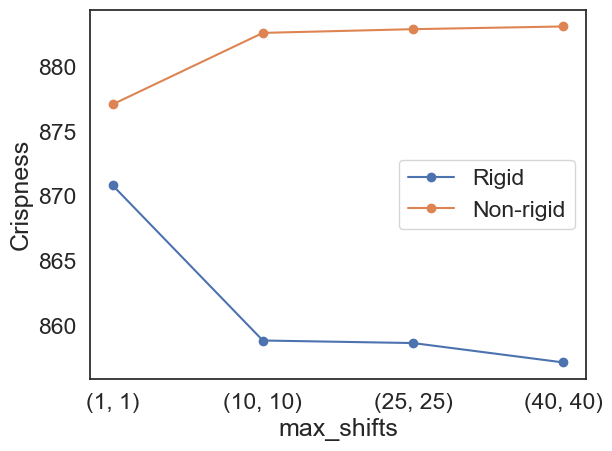

In [6]:
# values to test
shifts_list = [(1,1), (10,10), (25,25), (40,40)]
deviation_list = [1, 5, 15, 20]

# Define parameters for motion correction in a dictionary
parameters_motion_correction = { 'pw_rigid': True,       # flag for performing piecewise-rigid motion correction (otherwise just rigid)
                                'gSig_filt': (5, 5),     # size of high pass spatial filtering, used in 1p data
                                'niter_rig': 1 ,
                                'strides': (48, 48),     # create a new patch every x pixels for pw-rigid correction
                                'overlaps': (96, 96),    # overlap between pathes (size of patch strides+overlaps)
                                'upsample_factor_grid': 1,
                                'num_frames_split': 80,  # length in frames of each chunk of the movie (to be processed in parallel)
                                'shifts_opencv': True, 
                                'use_cuda': False, 
                                'nonneg_movie': True,
                                'border_nan': 'copy'}
original_movie = cm.load(input_tif_file_path)
parameters_motion_correction['min_mov'] = np.min(original_movie) 

crisp_rig = []
crisp_els = []

for max_shifts, max_dev in zip(shifts_list, deviation_list):

    # update parameters
    parameters_motion_correction['max_shifts'] = max_shifts
    parameters_motion_correction['max_deviation_rigid'] = max_dev

    opts = params.CNMFParams(params_dict=parameters_motion_correction)

    #create an object for motion correction
    mc = MotionCorrect(
        input_tif_file_path,
        dview=None,
        **opts.get_group('motion')
    )

    # run motion correction 
    mc.motion_correct_rigid(save_movie=True) # Perform rigid motion correction
    mc.motion_correct_pwrigid(save_movie=True, template=mc.total_template_rig) #perform non-rigid motion correction

    # crispness rigid
    tmpl_rig, correlations_rig, flows_rig, norms_rig, cr_rig = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_rig[0],
        mc.total_template_rig.shape[0],
        mc.total_template_rig.shape[1],
        swap_dim, winsize=winsize, play_flow=False, resize_fact_flow=resize_fact_flow
    )

    # crispness non-rigid
    tmpl_els, correlations_els, flows_els, norms_els, cr_els = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_els[0],
        mc.total_template_rig.shape[0],
        mc.total_template_rig.shape[1],
        swap_dim, winsize=winsize, play_flow=False, resize_fact_flow=resize_fact_flow
    )

    crisp_rig.append(cr_rig)
    crisp_els.append(cr_els)

labels = [str(s) for s in shifts_list]

plt.plot(labels, crisp_rig, marker='o', label='Rigid')
plt.plot(labels, crisp_els, marker='o', label='Non-rigid')

plt.xlabel("max_shifts")
plt.ylabel("Crispness")
plt.legend()
plt.show()

> For rigid motion correction we see that we need to find a 'sweet spot' for the maximum shifts since this directly effects the complete frame shift in a xy direction. For non-rigid motion correction we see that the higher the maximum deviation, the better the crispness will be and thus allowing the number of pixels the patch can be shifted to be higher is beneficial in this case. 

## Crispness compared to different strides and overlaps

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
Movie average is negative. Removing 1st percentile.
In setting CNMFParam

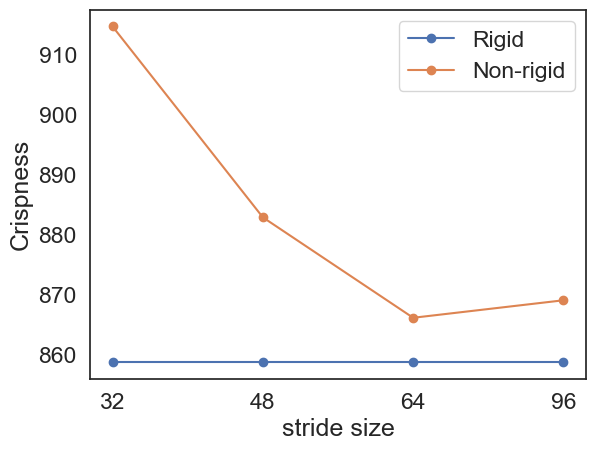

In [7]:
stride_list = [(32,32), (48,48), (64,64), (96,96)]
overlap_list = [(48, 48), (96, 96),  (128, 128), (192, 192) ]

# Define parameters for motion correction in a dictionary
parameters_motion_correction = { 'pw_rigid': True,       # flag for performing piecewise-rigid motion correction (otherwise just rigid)
                                'gSig_filt': (5, 5),     # size of high pass spatial filtering, used in 1p data
                                'max_shifts': (25, 25),  # maximum allowed rigid shift in pixels (view the movie to get a sense of motion)
                                'niter_rig': 1 ,
                                'upsample_factor_grid': 1,
                                'num_frames_split': 80,  # length in frames of each chunk of the movie (to be processed in parallel)
                                'max_deviation_rigid': 15, # maximum deviation allowed for patch with respect to rigid shifts
                                'shifts_opencv': True, 
                                'use_cuda': False, 
                                'nonneg_movie': True,
                                'border_nan': 'copy'}
original_movie = cm.load(input_tif_file_path)
parameters_motion_correction['min_mov'] = np.min(original_movie) 

crisp_rig = []
crisp_els = []

for strides, overlaps in zip(stride_list, overlap_list):

    # update parameters
    parameters_motion_correction['strides'] = strides
    parameters_motion_correction['overlaps'] = overlaps

    opts = params.CNMFParams(params_dict=parameters_motion_correction)

    mc = MotionCorrect(
        input_tif_file_path,
        dview=None,
        **opts.get_group('motion')
    )

    # motion correction
    mc.motion_correct_rigid(save_movie=True)
    mc.motion_correct_pwrigid(save_movie=True, template=mc.total_template_rig)

    # crispness rigid
    tmpl_rig, correlations_rig, flows_rig, norms_rig, cr_rig = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_rig[0],
        mc.total_template_rig.shape[0],
        mc.total_template_rig.shape[1],
        swap_dim, winsize=winsize, play_flow=False, resize_fact_flow=resize_fact_flow
    )

    # crispness non-rigid
    tmpl_els, correlations_els, flows_els, norms_els, cr_els = cm.motion_correction.compute_metrics_motion_correction(
        mc.fname_tot_els[0],
        mc.total_template_rig.shape[0],
        mc.total_template_rig.shape[1],
        swap_dim, winsize=winsize, play_flow=False, resize_fact_flow=resize_fact_flow
    )

    crisp_rig.append(cr_rig)
    crisp_els.append(cr_els)

labels = [str(s[0]) for s in stride_list]

plt.plot(labels, crisp_rig, marker='o', label='Rigid')
plt.plot(labels, crisp_els, marker='o', label='Non-rigid')

plt.xlabel("stride size")
plt.ylabel("Crispness")
plt.legend()
plt.show()

> Firstly we see that the rigid motion correction is not effected by the stride/overlap sizes, which is what we expected. For non-rigid motion correction we see that the smaller the patch sizes, the preciser the correction can be. However a very big stride size seems to then also give a better crispness.

# Exercise 3

In [8]:
import psutil
from pathlib import Path
n_processes = psutil.cpu_count() # counts local cpus
cm.cluster.stop_server() #stop any already running clusters
# Start a new cluster
c, dview, n_processes = cm.cluster.setup_cluster(backend='multiprocessing',
                                                 n_processes=n_processes,
                                                 single_thread=False)

# load motion corrected video
input_mmap_file_path = 'data/motion_corrected/motion_corrected_video_d1_300_d2_400_d3_1_order_C_frames_500.mmap'
Yr, dims, T = cm.load_memmap(input_mmap_file_path)         # load mmap file
images = Yr.T.reshape((T,) + dims, order='F' )

# compute correlation and pnr images 
gSig = 9
corr_image, pnr_image = cm.summary_images.correlation_pnr(images[::1], gSig=gSig,swap_dim=False)

## Range of possible PNR minimun values

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
/Users/zoedekker/miniforge3/envs/caiman/lib/python3.10/site-packages/scipy/sparse/_dia.py:298: RuntimeWarning: divide by zero encountered in remainder
  c = np.arange(num_rows, dtype=np.intc) - (offsets % max_dim)[:, None]
/Users/zoedekker/miniforge3/envs/caiman/lib/python3.10/site-packages/scipy/sparse/_dia.py:298: RuntimeWarning: divide by zero encountered in remainder
  c = np.arange(num_rows, dtype=np.intc) - (offsets % max_dim)[:, None]
/Users/zoedekker/miniforge3/envs/caiman/lib/python3.10/site-packages/scipy/sparse/_dia.py:298: RuntimeWarning: divide by zero encountered in remainder
  c = np.arange(num_rows, dtype=np.intc) - (offsets % max_dim)[:, None]
/Users/zoedekker/miniforge3/envs/caiman/lib/python3.10/site-packages/scipy/sparse/_dia.py:298: RuntimeWarning: divide by zero encountered in remainder
  

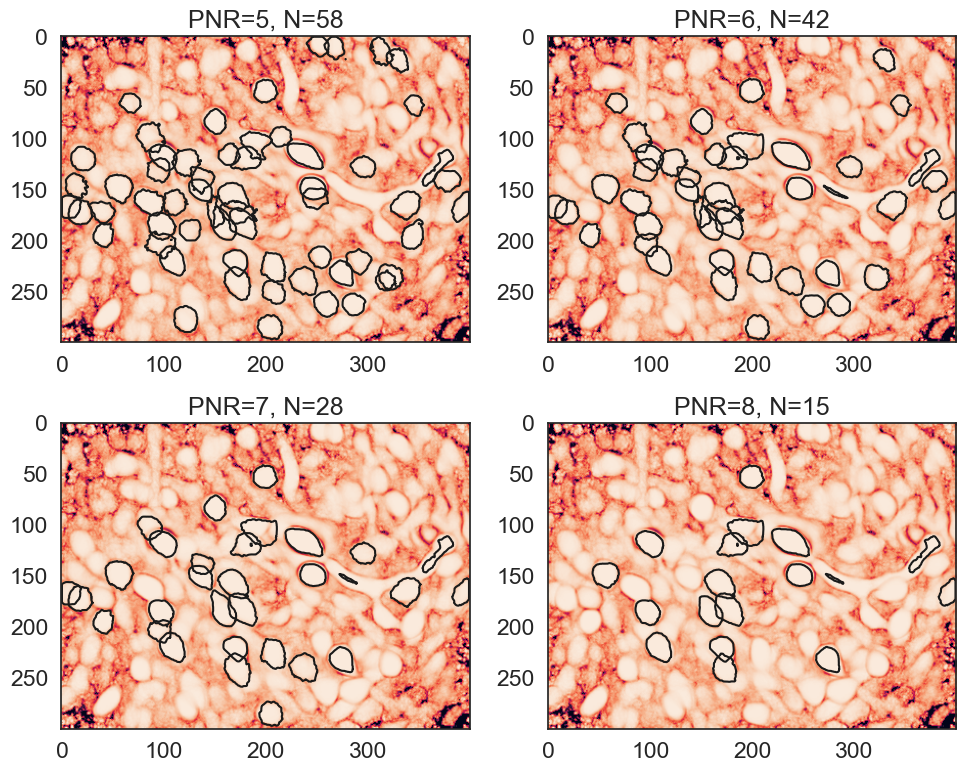

In [9]:
# create dictionary with source extraction parameters
parameters_source_extraction ={ 'fr': 10,               # movie frame rate
                               'decay_time': 0.1,       # length of a typical transient in seconds
                               'min_corr': 0.6,   # min peak value from correlation image, i.e. 0.6
                                'p': 1,                # order of the autoregressive system 
                               'K': None,              # upper bound on number of components per patch, in general None
                               'gSig': (4, 4),         # gaussian width of a 2D gaussian kernel, which approximates a neuron
                               'gSiz': (17, 17),       # average diameter of a neuron, in general 4*gSig+1
                               'ring_size_factor': 1.4, # radius of ring is gSiz*ring_size_factor
                               'merge_thr': 0.7, 'rf': 60,
                               'stride': 30, 'tsub': 1, 'ssub': 2, 'p_tsub': 1, 'p_ssub': 2, 'low_rank_background': None,
                               'nb': 0, 'nb_patch': 0, 'ssub_B': 2, 'init_iter': 2,
                               'method_init': 'corr_pnr', 'method_deconvolution': 'oasis',
                               'update_background_components': True,
                               'center_psf': True, 'border_pix': 0, 'normalize_init': False,
                               'del_duplicates': True, 'only_init': True}

PNR_values = [5,6,7,8] #range of pnr values
results = []
n_components_pnr = [] #will count the number of neurons

for min_pnr in PNR_values:
    # update parameters
    parameters_source_extraction['min_pnr'] = min_pnr
    # create caiman parameters objects
    opts = params.CNMFParams(params_dict=parameters_source_extraction)

    cnmf_object = cnmf.CNMF(n_processes=n_processes, dview=dview, params=opts)
    cnmf_object.fit(images)

    results.append(cnmf_object)
    n_components_pnr.append(cnmf_object.estimates.A.shape[1])

#plot spatial source extraction
fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for i, min_pnr in enumerate(PNR_values):
    cnmf_object = results[i]
    ax = axes[i]
    ax.imshow(corr_image)
    ax.set_title(f'PNR={min_pnr}, N={cnmf_object.estimates.A.shape[1]}')
    coordinates = cm.utils.visualization.get_contours(cnmf_object.estimates.A, np.shape(corr_image), 0.2, 'max') #contour the detected neurons
    for c in coordinates:
        v = c['coordinates']
        ax.plot(*v.T, c='k')

plt.tight_layout()
plt.show()


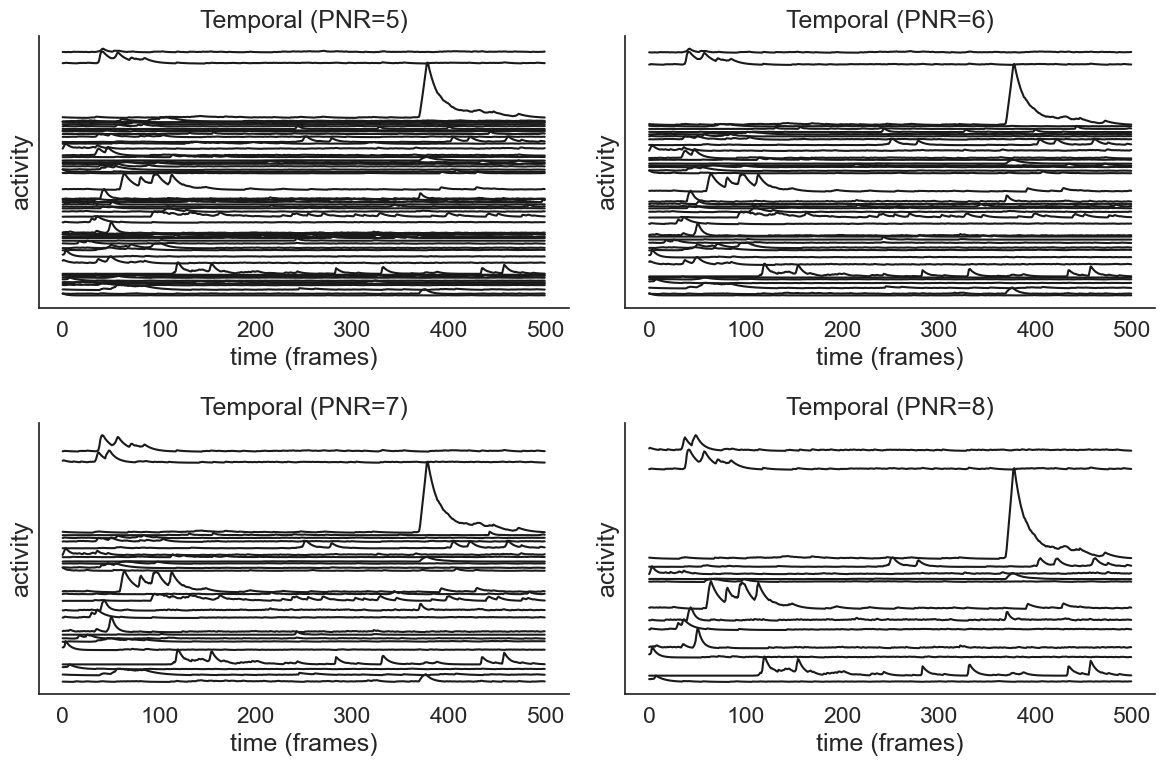

In [10]:
#plot temporal trace source extraction
figure, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.ravel()

for i, min_pnr in enumerate(PNR_values):
    cnmf_object = results[i]
    C_0 = cnmf_object.estimates.C.copy()
    ax = axes[i]
    C_0[1] += C_0[0].min()
    for j in range(1, len(C_0)):
        C_0[j] += C_0[j].min() + C_0[:j].max()
        ax.plot(C_0[j], c='k')
    ax.set_title(f"Temporal (PNR={min_pnr})")
    ax.set_xlabel("time (frames)")
    ax.set_yticks([])
    sns.despine(ax=ax)
    ax.set_ylabel("activity")
plt.tight_layout()
plt.show()


> We see that for the same minimum correlation value (ie 0.6), the minimum PNR values effects how many neuron (N) the code finds. If the peak to noise ratio is high it means that pixels that are considered to be part of a neuron must show very high peaks compared to the background noise and so less pixels are assigned to a neuron. A low PNR will therefore assign background pixels to neurons because just a small spike caused by noise can already be seen as a neuron firing. As for the temporal traces, these do not change only the amount of traces we see changes.

## Range of minimum correlation values

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
/Users/zoedekker/miniforge3/envs/caiman/lib/python3.10/site-packages/scipy/sparse/_dia.py:298: RuntimeWarning: divide by zero encountered in remainder
  c = np.arange(num_rows, dtype=np.intc) - (offsets % max_dim)[:, None]
/Users/zoedekker/miniforge3/envs/caiman/lib/python3.10/site-packages/scipy/sparse/_dia.py:298: RuntimeWarning: divide by zero encountered in remainder
  c = np.arange(num_rows, dtype=np.intc) - (offsets % max_dim)[:, None]
/Users/zoedekker/miniforge3/envs/caiman/lib/python3.10/site-packages/scipy/sparse/_dia.py:298: RuntimeWarning: divide by zero encountered in remainder
  c = np.arange(num_rows, dtype=np.intc) - (offsets % max_dim)[:, None]
/Users/zoedekker/miniforge3/envs/caiman/lib/python3.10/site-packages/scipy/sparse/_dia.py:298: RuntimeWarning: divide by zero encountered in remainder
  

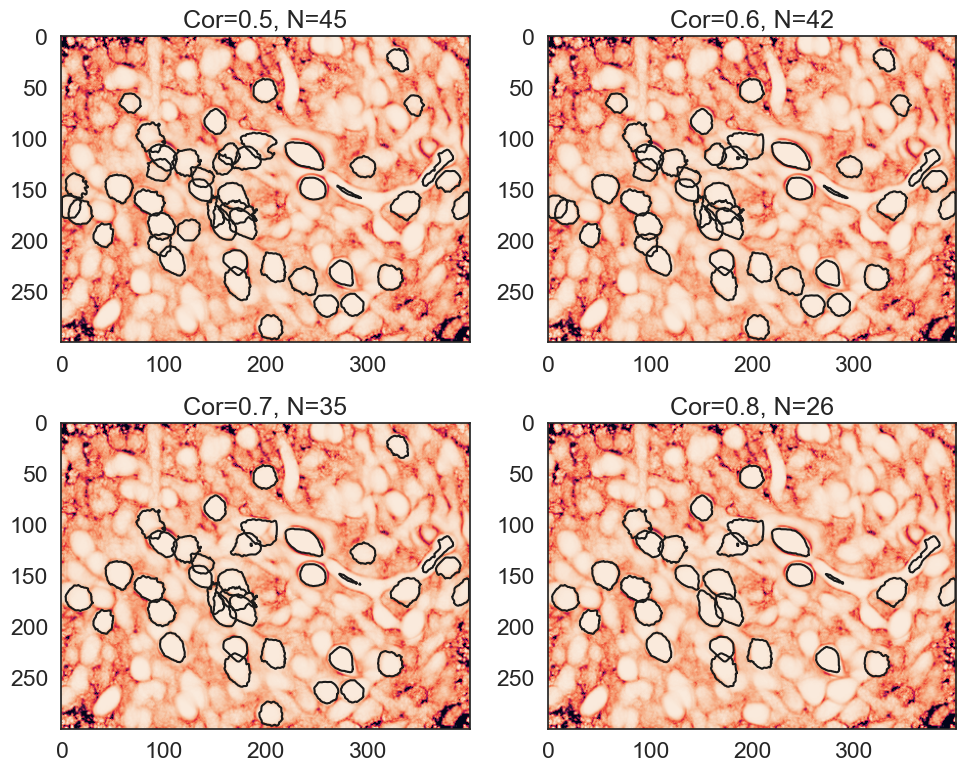

In [11]:
# create dictionary with source extraction parameters
parameters_source_extraction ={ 'fr': 10,               # movie frame rate
                               'decay_time': 0.1,       # length of a typical transient in seconds
                                'min_pnr': 6,     # min peak to noise ration from PNR image, ie 6
                                'p': 1,                # order of the autoregressive system 
                               'K': None,              # upper bound on number of components per patch, in general None
                               'gSig': (4, 4),         # gaussian width of a 2D gaussian kernel, which approximates a neuron
                               'gSiz': (17, 17),       # average diameter of a neuron, in general 4*gSig+1
                               'ring_size_factor': 1.4, # radius of ring is gSiz*ring_size_factor
                               'merge_thr': 0.7, 'rf': 60,
                               'stride': 30, 'tsub': 1, 'ssub': 2, 'p_tsub': 1, 'p_ssub': 2, 'low_rank_background': None,
                               'nb': 0, 'nb_patch': 0, 'ssub_B': 2, 'init_iter': 2,
                               'method_init': 'corr_pnr', 'method_deconvolution': 'oasis',
                               'update_background_components': True,
                               'center_psf': True, 'border_pix': 0, 'normalize_init': False,
                               'del_duplicates': True, 'only_init': True}

cor_values = [.5,.6,.7,.8]
results = []
n_components_cor = []

for min_cor in cor_values:
    # update parameters
    parameters_source_extraction['min_corr'] = min_cor
    # create caiman parameters objects
    opts = params.CNMFParams(params_dict=parameters_source_extraction)

    cnmf_object = cnmf.CNMF(n_processes=n_processes, dview=dview, params=opts)
    cnmf_object.fit(images)

    results.append(cnmf_object)
    n_components_cor.append(cnmf_object.estimates.A.shape[1])

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for i, min_cor in enumerate(cor_values):
    cnmf_object = results[i]
    ax = axes[i]
    ax.imshow(corr_image)
    ax.set_title(f'Cor={min_cor}, N={cnmf_object.estimates.A.shape[1]}')
    coordinates = cm.utils.visualization.get_contours(cnmf_object.estimates.A,np.shape(corr_image),0.2,'max')
    for c in coordinates:
        v = c['coordinates']
        ax.plot(*v.T, c='k')

plt.tight_layout()
plt.show()

> The higher the correlation value, the lower the amount of neurons it finds. This makes sense because if only pixels that are highly correlated are considered neurons, the code will find less neurons. However a low correlation is not neccessary better because then it could just as easily assign background pixels to neurons since their correlation does not need to be so high.

## Number of neurons

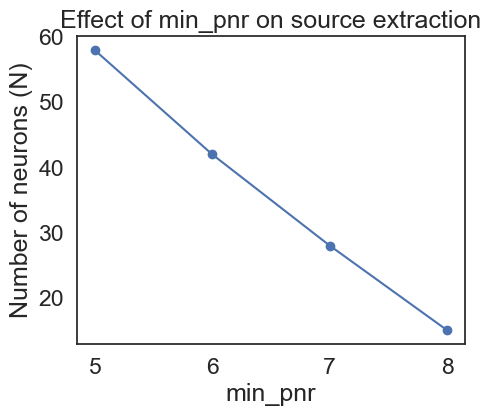

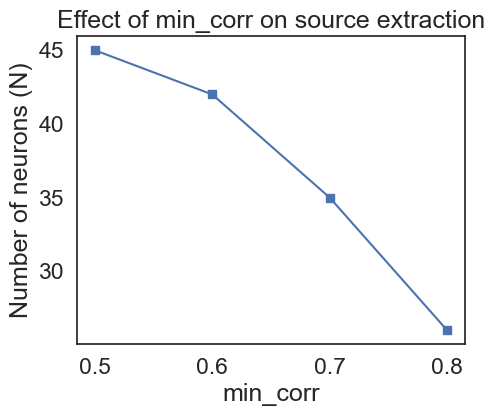

In [12]:
plt.figure(figsize=(5,4))
plt.plot(PNR_values, n_components_pnr, marker='o')
plt.xlabel("min_pnr")
plt.ylabel("Number of neurons (N)")
plt.title("Effect of min_pnr on source extraction")
plt.show()

plt.figure(figsize=(5,4))
plt.plot(cor_values, n_components_cor, marker='s')
plt.xlabel("min_corr")
plt.ylabel("Number of neurons (N)")
plt.title("Effect of min_corr on source extraction")
plt.show()

> So again we see that these parameters effect which neurons and thus the amount of neurons that are selected.

## Temporal traces
Changing min_pnr or min_corr results in different neurons being selected so you get a different set of traces for a different amount of neurons. So that way it is indireclty effected. But for a detected neuron, its trace shape (C) is based on the data not on the minimum values of the parameters. This can be seen in the previous printed plot.

## Correlation image

In setting CNMFParams, non-pathed parameters were used; this is deprecated. In some future version of Caiman, allow_legacy will default to False (and eventually will be removed)
/Users/zoedekker/miniforge3/envs/caiman/lib/python3.10/site-packages/scipy/sparse/_dia.py:298: RuntimeWarning: divide by zero encountered in remainder
  c = np.arange(num_rows, dtype=np.intc) - (offsets % max_dim)[:, None]
/Users/zoedekker/miniforge3/envs/caiman/lib/python3.10/site-packages/scipy/sparse/_dia.py:298: RuntimeWarning: divide by zero encountered in remainder
  c = np.arange(num_rows, dtype=np.intc) - (offsets % max_dim)[:, None]
/Users/zoedekker/miniforge3/envs/caiman/lib/python3.10/site-packages/scipy/sparse/_dia.py:298: RuntimeWarning: divide by zero encountered in remainder
  c = np.arange(num_rows, dtype=np.intc) - (offsets % max_dim)[:, None]
/Users/zoedekker/miniforge3/envs/caiman/lib/python3.10/site-packages/scipy/sparse/_dia.py:298: RuntimeWarning: divide by zero encountered in remainder
  

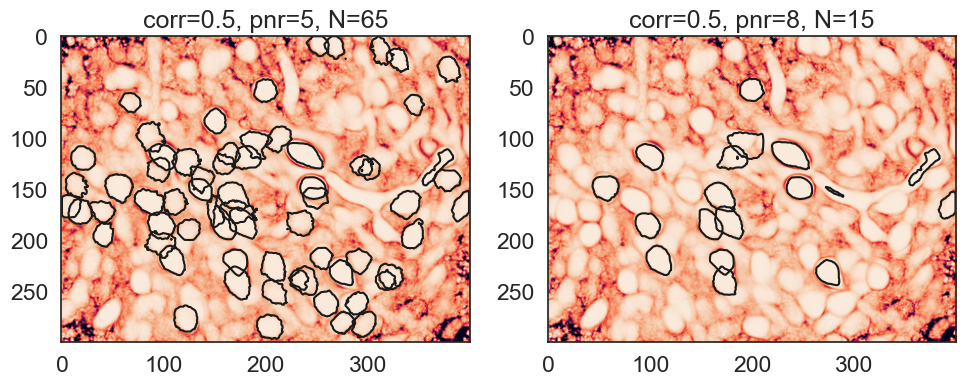

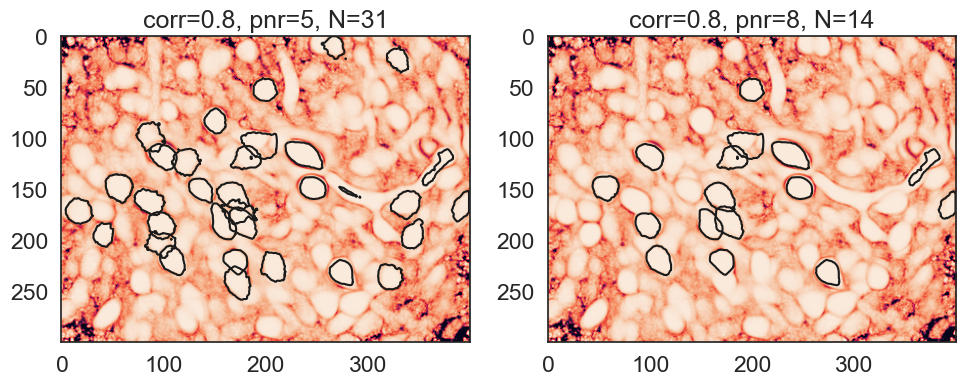

In [13]:
results = {}
PNR_values=[5,8]
cor_values=[.5,.8]

for min_corr in cor_values:
    for min_pnr in PNR_values:

        parameters_source_extraction['min_corr'] = min_corr
        parameters_source_extraction['min_pnr'] = min_pnr

        opts = params.CNMFParams(params_dict=parameters_source_extraction)

        cnmf_object = cnmf.CNMF(n_processes=n_processes, dview=dview, params=opts)
        cnmf_object.fit(images)

        results[(min_corr, min_pnr)] = cnmf_object

for min_corr in cor_values:

    fig, axes = plt.subplots(1, 2, figsize=(10, 8))
    axes = axes.ravel()

    for i, min_pnr in enumerate(PNR_values):

        cnmf_object = results[(min_corr, min_pnr)]
        ax = axes[i]

        ax.imshow(corr_image)
        ax.set_title(f"corr={min_corr}, pnr={min_pnr}, N={cnmf_object.estimates.A.shape[1]}")

        coords = cm.utils.visualization.get_contours(cnmf_object.estimates.A,np.shape(corr_image),0.2,'max')

        for c in coords:
            v = c['coordinates']
            ax.plot(*v.T, c='k')

    plt.tight_layout()
    plt.show()

> We see higher numbers of selected neurons when the minimum of the parameters are set lower.